<a href="https://colab.research.google.com/github/SpicyPump/CI345ML/blob/main/CI345_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Problem Definition & Dataset Selection

In [1]:
import pandas as pd
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download(
    "sharmajicoder/genn-z-college-admission-dataset"
)

print("Dataset folder:", path)

# See what files were downloaded
print(os.listdir(path))

Using Colab cache for faster access to the 'genn-z-college-admission-dataset' dataset.
Dataset folder: /kaggle/input/genn-z-college-admission-dataset
['genz_college_admission_prediction.csv']


The goal of this project is to determine whether a student will be admitted to a college based on academic, personal, and socioeconomic factors.

# Step 2: Data Analysis


In [2]:
csv_file = os.path.join(path, 'genz_college_admission_prediction.csv')

df = pd.read_csv(csv_file)
print(df.head())
print(df.shape)


   student_id  age gender     state  family_income  high_school_gpa  \
0           1   22   Male      Ohio          32560             3.20   
1           2   19   Male  Virginia          39084             4.00   
2           3   20   Male      Ohio          21615             2.90   
3           4   22   Male  Illinois         109493             3.86   
4           5   18   Male   Florida          50314             2.50   

   sat_score  act_score  attendance_rate  ap_courses  extracurricular_count  \
0        734         27             91.0           3                      3   
1        988         26            100.0           0                      5   
2       1600         28             97.7           2                      3   
3       1302         28             91.6           4                      3   
4       1342         30             91.8           3                      4   

   volunteer_hours  leadership_positions  coding_projects  social_media_hours  \
0               8

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  object 
 3   state                  1000000 non-null  object 
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null  int64  
 7   act_score              1000000 non-null  int64  
 8   attendance_rate        1000000 non-null  float64
 9   ap_courses             1000000 non-null  int64  
 10  extracurricular_count  1000000 non-null  int64  
 11  volunteer_hours        1000000 non-null  int64  
 12  leadership_positions   1000000 non-null  int64  
 13  coding_projects        1000000 non-null  int64  
 14  social_media_hours 

In [4]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
state,0
family_income,0
high_school_gpa,0
sat_score,0
act_score,0
attendance_rate,0
ap_courses,0


In [5]:
df.describe()

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,19.000294,71701.069023,3.188329,1099.198467,23.468139,91.748151,2.999739,3.999927,99.452955,1.201223,1.999254,4.506180,1.997953,74.912247,77.954531,72.775141,0.881292
std,288675.278933,1.999321,47253.555181,0.476299,217.409113,5.908590,5.526156,1.729285,2.001495,50.019098,1.095605,1.414804,1.790163,1.414445,11.805257,9.873768,14.522840,0.323445
min,1.000000,16.000000,2124.000000,0.870000,400.000000,1.000000,63.200000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,17.600000,28.800000,0.500000,0.000000
25%,250000.750000,17.000000,39953.000000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000,1.000000
50%,500000.500000,19.000000,59877.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,73.000000,1.000000
75%,750000.250000,21.000000,89688.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000,1.000000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,517.000000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000,1.000000


In [6]:
print(df.columns)

Index(['student_id', 'age', 'gender', 'state', 'family_income',
       'high_school_gpa', 'sat_score', 'act_score', 'attendance_rate',
       'ap_courses', 'extracurricular_count', 'volunteer_hours',
       'leadership_positions', 'coding_projects', 'social_media_hours',
       'online_certifications', 'essay_score', 'recommendation_score',
       'interview_score', 'admission_status'],
      dtype='object')


In [7]:
print(df['admission_status'].value_counts())

admission_status
1    881292
0    118708
Name: count, dtype: int64


# Step 3: Data Visualization

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
state,object
family_income,int64
high_school_gpa,float64
sat_score,int64
act_score,int64
attendance_rate,float64
ap_courses,int64


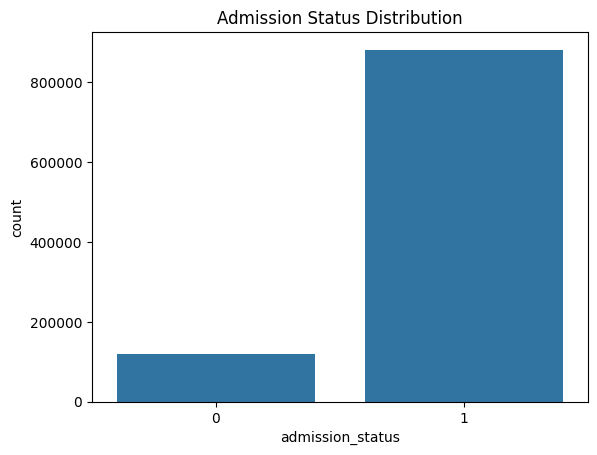

In [10]:
sns.countplot(
    x='admission_status',
    data=df
)

plt.title("Admission Status Distribution")
plt.show()

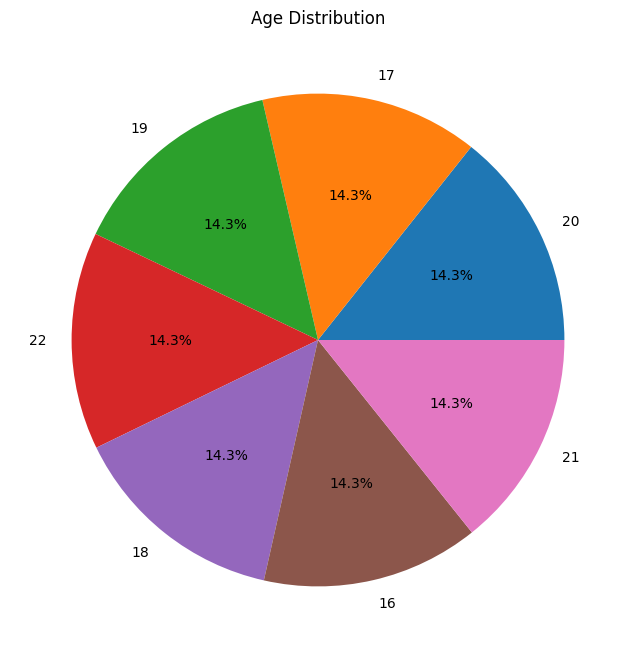

In [11]:
age_counts = df['age'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
)
plt.title("Age Distribution")
plt.show()

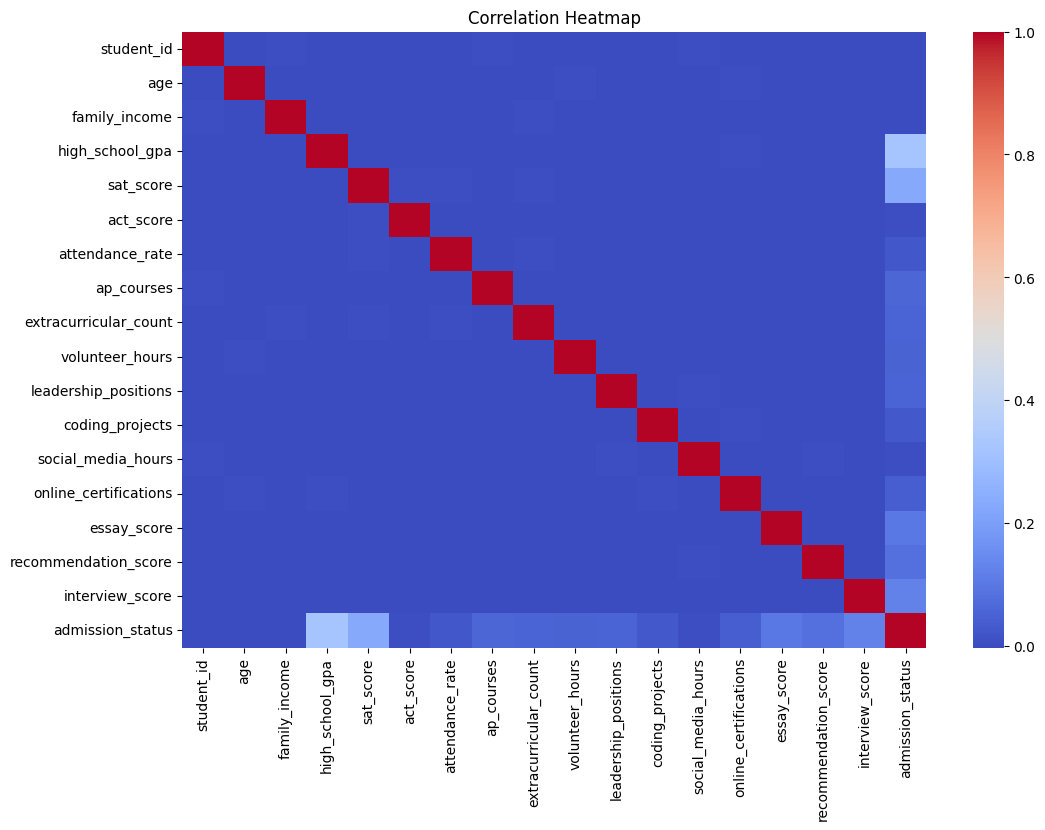

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

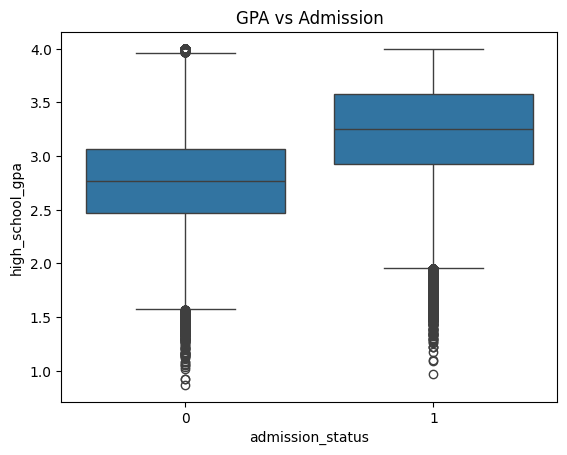

In [13]:
sns.boxplot(
    x='admission_status',
    y='high_school_gpa',
    data=df
)

plt.title("GPA vs Admission")
plt.show()


# Step 4 Data Preprocessing


In [35]:
df.select_dtypes(include='object').columns

Index(['gender', 'state'], dtype='object')

In [36]:
categorical_cols = [
    'gender',
    'state'
]

In [37]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# One-Hot Encoding

In [38]:
print(df_encoded['admission_status'].unique())

[1 0]


# Step 5: Machine Learning Models

In [48]:
X = df_encoded.drop('admission_status', axis=1)

y = df_encoded['admission_status']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

AdaBoost is an ensemble learning algorithm that combines many weak classifiers into a stronger classifier. It works by repeatedly training small decision trees and assigning greater importance to observations that were previously misclassified. The final prediction is determined by combining the predictions of all trees through weighted voting. In this project, AdaBoost was used to predict college admission decisions based on academic, personal, and socioeconomic factors.

In [53]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=20,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))

Accuracy: 0.88638
Precision: 0.8886105290860689
Recall: 0.9959442288929731
F1 Score: 0.9392208153461824
